<a href="https://colab.research.google.com/github/Nagata2442/Nagata2442/blob/main/Poverty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/Dataset_Kemiskinan (5).csv")
df.head()

,Provinsi,KabKota,Kemiskinan,RLS,Pengeluaran,IPM,UHH,Sanitasi,AirMinum,TPT,TPAK
0,ACEH,Simeulue,8.180556,9.480000,7148,66.41,65.28,71.56,87.45,2.576389,71.15
1,ACEH,Aceh Singkil,20.360000,3.805556,8776,69.22,67.43,69.56,78.58,8.360000,62.85
2,ACEH,Aceh Selatan,13.180000,3.944444,8180,67.44,64.04,62.55,79.65,6.460000,60.85
3,ACEH,Aceh Tenggara,13.410000,4.215278,8030,69.44,68.22,62.71,86.71,6.430000,69.62
4,ACEH,Aceh Timur,14.450000,8.210000,8577,67.83,68.74,66.75,83.16,7.130000,59.48


In [ ]:
df.shape

(532, 11)

In [ ]:
print("Jumlah data awal:", len(df))
print(df.info())
print(df.head())

Jumlah data awal: 532
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 532 entries, 0 to 531
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Provinsi     532 non-null    object 
 1   KabKota      532 non-null    object 
 2   Kemiskinan   532 non-null    float64
 3   RLS          532 non-null    float64
 4   Pengeluaran  532 non-null    int64  
 5   IPM          526 non-null    float64
 6   UHH          527 non-null    float64
 7   Sanitasi     531 non-null    float64
 8   AirMinum     529 non-null    float64
 9   TPT          532 non-null    float64
 10  TPAK         532 non-null    float64
dtypes: float64(8), int64(1), object(2)
memory usage: 45.8+ KB
None
  Provinsi        KabKota  Kemiskinan       RLS  Pengeluaran    IPM    UHH  \
0     ACEH       Simeulue    8.180556  9.480000         7148  66.41  65.28   
1     ACEH   Aceh Singkil   20.360000  3.805556         8776  69.22  67.43   
2     ACEH   Aceh Selatan

In [ ]:
print("Data sebelum dropna():\n", df.isnull().sum())
df = df.dropna()
print("\nJumlah data kosong setelah dibersihkan:\n", df.isnull().sum())

Data sebelum dropna():
 Provinsi       0
KabKota        0
Kemiskinan     0
RLS            0
Pengeluaran    0
IPM            6
UHH            5
Sanitasi       1
AirMinum       3
TPT            0
TPAK           0
dtype: int64

Jumlah data kosong setelah dibersihkan:
 Provinsi       0
KabKota        0
Kemiskinan     0
RLS            0
Pengeluaran    0
IPM            0
UHH            0
Sanitasi       0
AirMinum       0
TPT            0
TPAK           0
dtype: int64


In [ ]:
df.duplicated().sum()

np.int64(15)

In [ ]:
df_clean = df.drop_duplicates().copy()

In [ ]:
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
df_clean["Provinsi"] = df_clean["Provinsi"].str.strip()
df_clean["KabKota"] = df_clean["KabKota"].str.strip()

Jumlah data outlier: 44


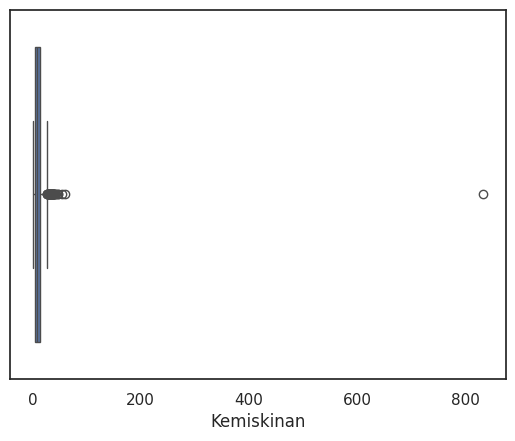

In [ ]:
Q1 = df_clean['Kemiskinan'] . quantile (0.25)
Q3 = df_clean['Kemiskinan'] . quantile (0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

jumlah_outlier = ((df_clean['Kemiskinan'] < lower_bound) | (df_clean['Kemiskinan'] > upper_bound)).sum()
print("Jumlah data outlier:", jumlah_outlier)

sns.boxplot(x=df_clean['Kemiskinan'])
plt.show()

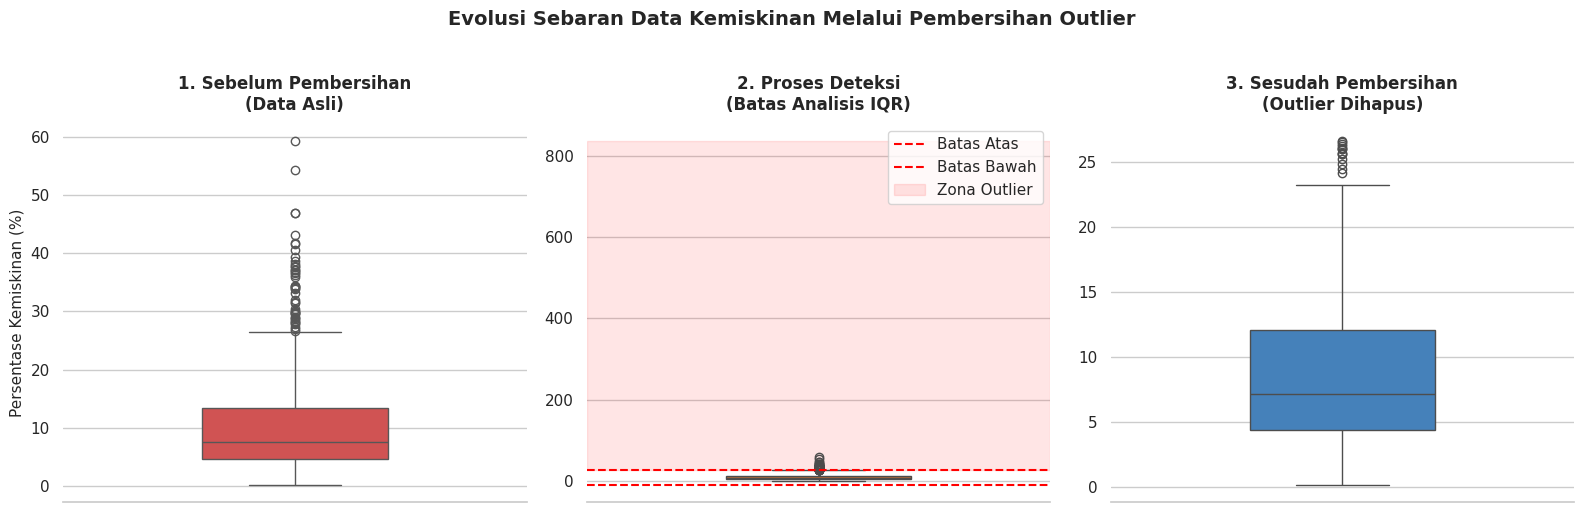

In [ ]:
sns.set_theme(style="whitegrid")
fig1, axes1 = plt.subplots(1, 3, figsize=(16, 5))

# Plot Sebelum
sns.boxplot(data=df_clean, y='Kemiskinan', ax=axes1[0], color='#E53E3E', width=0.4)
axes1[0].set_title('1. Sebelum Pembersihan\n(Data Asli)', fontsize=12, fontweight='bold', pad=10)
axes1[0].set_ylabel('Persentase Kemiskinan (%)', fontsize=11)

# Plot Proses Deteksi
sns.boxplot(data=df_clean, y='Kemiskinan', ax=axes1[1], color='#DD6B20', width=0.4)
axes1[1].axhline(upper_bound, color='red', linestyle='--', linewidth=1.5, label='Batas Atas')
axes1[1].axhline(lower_bound, color='red', linestyle='--', linewidth=1.5, label='Batas Bawah')
axes1[1].axhspan(upper_bound, df['Kemiskinan'].max() + 2, color='red', alpha=0.1, label='Zona Outlier')
axes1[1].set_title('2. Proses Deteksi\n(Batas Analisis IQR)', fontsize=12, fontweight='bold', pad=10)
axes1[1].set_ylabel('')
axes1[1].legend(loc='upper right')

# Plot Sesudah
sns.boxplot(data=df_final, y='Kemiskinan', ax=axes1[2], color='#3182CE', width=0.4)
axes1[2].set_title('3. Sesudah Pembersihan\n(Outlier Dihapus)', fontsize=12, fontweight='bold', pad=10)
axes1[2].set_ylabel('')

plt.suptitle('Evolusi Sebaran Data Kemiskinan Melalui Pembersihan Outlier', fontsize=14, fontweight='bold', y=1.02)
sns.despine(left=True)
plt.tight_layout()
plt.savefig('1_evolusi_pembersihan_outlier.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print((df_clean["Kemiskinan"] > 100).sum())

median_kemiskinan = df_clean[df_clean["Kemiskinan"]<= 100]["Kemiskinan"].median()
df_clean.loc[df_clean["Kemiskinan"] > 100, "Kemiskinan"] = median_kemiskinan

print("Kemiskinan tertinggi sekarang:", df_clean["Kemiskinan"].max())

0
Kemiskinan tertinggi sekarang: 59.375


In [ ]:
print("Jumlah provinsi:", df_clean["Provinsi"].nunique())
print("Jumlah KabKota:", len(df_clean))

df_clean.groupby("Provinsi")["Kemiskinan"].mean().sort_values(ascending=False).head(10)

Jumlah provinsi: 34
Jumlah KabKota: 502


,Kemiskinan
Provinsi,
PAPUA,28.652073
PAPUA BARAT,24.218761
NUSA TENGGARA TIMUR,19.337311
MALUKU,17.711061
SULAWESI TENGAH,14.556709
GORONTALO,13.461759
JAMBI,13.306540
ACEH,12.993631
SUMATERA SELATAN,12.550451


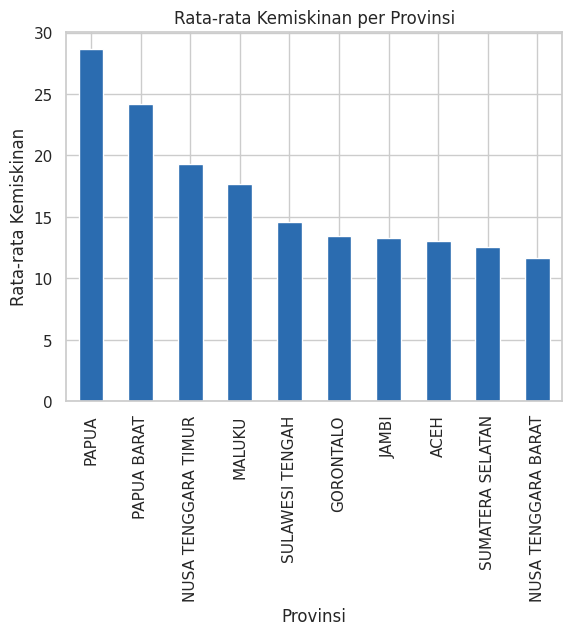

In [ ]:
rata_provinsi = df_clean.groupby("Provinsi")["Kemiskinan"].mean().sort_values(ascending=False).head(10)
rata_provinsi.plot(kind="bar", color="#2B6CB0")
plt.title("Rata-rata Kemiskinan per Provinsi")
plt.xlabel("Provinsi")
plt.ylabel("Rata-rata Kemiskinan")
plt.show()

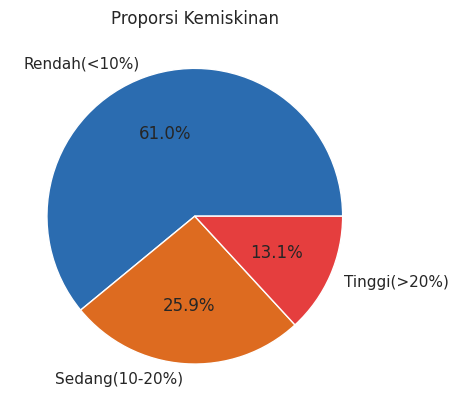

In [ ]:
rendah = (df_clean["Kemiskinan"] < 10).sum()
sedang = ((df_clean["Kemiskinan"] >= 10) & (df_clean["Kemiskinan"] <= 20)).sum()
tinggi = (df_clean["Kemiskinan"] > 20).sum()

plt.pie([rendah, sedang, tinggi], labels=["Rendah(<10%)", "Sedang(10-20%)", "Tinggi(>20%)"], autopct="%1.1f%%", colors=["#2B6CB0", "#DD6B20", "#E53E3E"])
plt.title("Proporsi Kemiskinan")
plt.show()

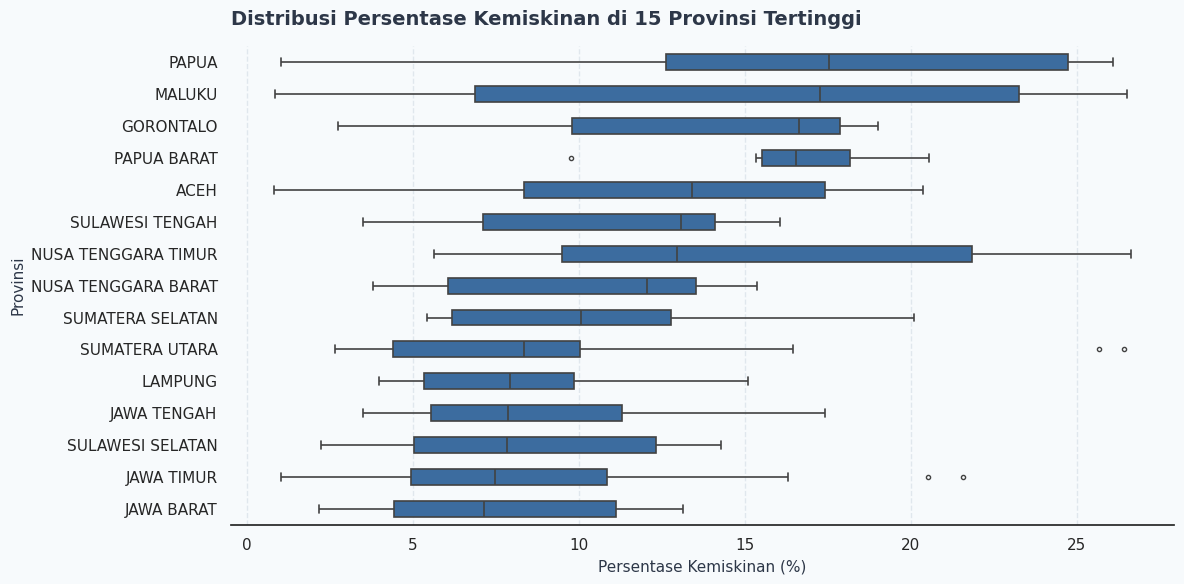

In [ ]:
sns.set_theme(style="white")
# Mengurutkan provinsi berdasarkan median kemiskinan tertinggi (ambil top 15 agar rapi)
provinsi_order = df_final.groupby('Provinsi')['Kemiskinan'].median().sort_values(ascending=False).index[:15]
df_top_prov = df_final[df_final['Provinsi'].isin(provinsi_order)]

fig2, ax2 = plt.subplots(figsize=(12, 6), facecolor='#F7FAFC')
ax2.set_facecolor('#F7FAFC')

sns.boxplot(
    data=df_top_prov,
    x='Kemiskinan',
    y='Provinsi',
    order=provinsi_order,
    color='#2B6CB0',
    width=0.5,
    linewidth=1.2,
    fliersize=3,
    ax=ax2
)

ax2.set_title('Distribusi Persentase Kemiskinan di 15 Provinsi Tertinggi', fontsize=14, fontweight='bold', color='#2D3748', pad=15, loc='left')
ax2.set_xlabel('Persentase Kemiskinan (%)', fontsize=11, color='#2D3748')
ax2.set_ylabel('Provinsi', fontsize=11, color='#2D3748')
sns.despine(left=True, bottom=False)
ax2.grid(axis='x', linestyle='--', alpha=0.5, color='#CBD5E0')

plt.tight_layout()
plt.savefig('2_distribusi_kemiskinan_provinsi.png', dpi=300, facecolor=fig2.get_facecolor())
plt.show()

In [ ]:
rata_semua =df_clean

In [ ]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default

creds, _ = default()
gc = gspread.authorize(creds)

In [ ]:
sheet = gc.create('Data_Looker_Studio')
worksheet = sheet.sheet1

In [ ]:
from gspread_dataframe import set_with_dataframe

set_with_dataframe(worksheet, df)

In [ ]:
print(f"\n▸ Ukuran dataset : {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"▸ Data duplikat : {df.duplicated().sum()}")
print(f"▸ Data kosong : {df.isnull().sum().sum()}")
# ── Statistik deskriptif ─────────────────────────────────
print("\n▸ Statistik Deskriptif — Provinsi:")
print(df_clean['Kemiskinan'].describe().rename({
'count': 'Jumlah', 'mean': 'Rata-rata', 'std': 'Std Dev',
'min': 'Minimum', '25%': 'Q1', '50%': 'Median',
'75%': 'Q3', 'max': 'Maksimum'
}).to_string())


▸ Ukuran dataset : 517 baris × 11 kolom
▸ Data duplikat : 15
▸ Data kosong : 0

▸ Statistik Deskriptif — Provinsi:
Jumlah       502.000000
Rata-rata     12.511874
Std Dev       37.929951
Minimum        0.150000
Q1             4.644097
Median         7.532361
Q3            13.477500
Maksimum     834.000000


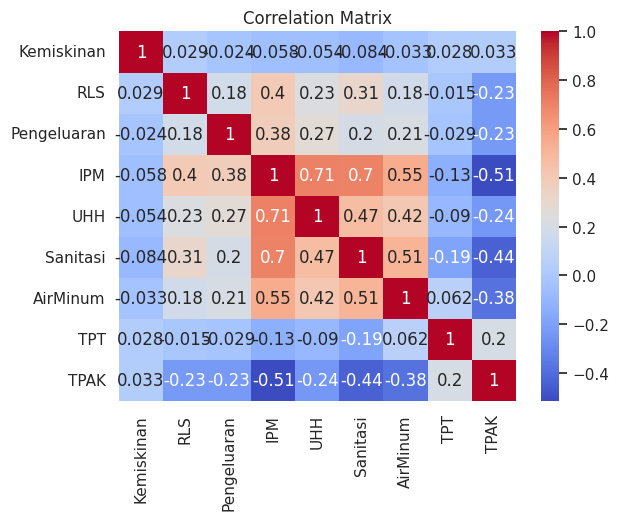

In [ ]:
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
df

,Provinsi,KabKota,Kemiskinan,RLS,Pengeluaran,IPM,UHH,Sanitasi,AirMinum,TPT,TPAK
0,ACEH,Simeulue,8.180556,9.480000,7148,66.41,65.28,71.56,87.45,2.576389,71.15
1,ACEH,Aceh Singkil,20.360000,3.805556,8776,69.22,67.43,69.56,78.58,8.360000,62.85
2,ACEH,Aceh Selatan,13.180000,3.944444,8180,67.44,64.04,62.55,79.65,6.460000,60.85
3,ACEH,Aceh Tenggara,13.410000,4.215278,8030,69.44,68.22,62.71,86.71,6.430000,69.62
4,ACEH,Aceh Timur,14.450000,8.210000,8577,67.83,68.74,66.75,83.16,7.130000,59.48
...,...,...,...,...,...,...,...,...,...,...,...
525,PAPUA,Puncak,36.260000,2.160000,5412,43.17,65.86,11.43,85.03,65.277778,89.43
526,PAPUA,Dogiyai,28.810000,2.319444,5415,55.00,65.85,12.11,71.24,2.555556,78.20
527,PAPUA,Intan Jaya,41.660000,3.090000,5328,48.34,65.69,0.36,35.01,1.430000,75.75
528,PAPUA,Deiyai,40.590000,3.250000,4673,49.96,65.36,0.00,85.23,54.861111,85.01


In [ ]:
df.to_csv("df_clean.csv")